In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

SPLIT_DIR = Path("../data/splits")

X_train = pd.read_csv(SPLIT_DIR / "X_train.csv")
X_val = pd.read_csv(SPLIT_DIR / "X_val.csv")
X_test = pd.read_csv(SPLIT_DIR / "X_test.csv")

y_train = pd.read_csv(
    SPLIT_DIR / "y_train.csv"
).squeeze()

y_val = pd.read_csv(
    SPLIT_DIR / "y_val.csv"
).squeeze()

y_test = pd.read_csv(
    SPLIT_DIR / "y_test.csv"
).squeeze()

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1764558, 70)
Validation: (378120, 70)
Test: (378120, 70)


In [3]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")

In [5]:
lr_model = joblib.load(
    MODEL_DIR / "logistic_regression.pkl"
)

rf_model = joblib.load(
    MODEL_DIR / "random_forest.pkl"
)

xgb_model = joblib.load(
    MODEL_DIR / "xgboost.pkl"
)

print("Classical models loaded.")

Classical models loaded.


In [6]:
y_val_pred_lr = lr_model.predict(X_val)
y_val_prob_lr = lr_model.predict_proba(X_val)[:, 1]

y_val_pred_rf = rf_model.predict(X_val)
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

In [7]:
import torch
import torch.nn as nn

In [8]:
input_size = X_train.shape[1]

class IDSNeuralNetwork(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

nn_model = IDSNeuralNetwork(
    input_size
).to(device)

nn_model.load_state_dict(
    torch.load(
        MODEL_DIR / "neural_network_baseline.pth",
        map_location=device
    )
)

nn_model.eval()

IDSNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=70, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [10]:
X_val_tensor = torch.tensor(
    X_val.values,
    dtype=torch.float32
).to(device)

with torch.no_grad():

    logits = nn_model(X_val_tensor)

    probabilities = torch.sigmoid(logits)

    y_val_prob_nn = (
        probabilities
        .cpu()
        .numpy()
        .ravel()
    )

    y_val_pred_nn = (
        y_val_prob_nn >= 0.5
    ).astype(int)

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

In [12]:
def calculate_metrics(y_true, y_pred, y_prob):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    pr_auc = average_precision_score(
        y_true,
        y_prob
    )

    fpr = fp / (fp + tn)

    fnr = fn / (fn + tp)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "FPR": fpr,
        "FNR": fnr,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [13]:
baseline_results = {

    "Logistic Regression": calculate_metrics(
        y_val,
        y_val_pred_lr,
        y_val_prob_lr
    ),

    "Random Forest": calculate_metrics(
        y_val,
        y_val_pred_rf,
        y_val_prob_rf
    ),

    "XGBoost": calculate_metrics(
        y_val,
        y_val_pred_xgb,
        y_val_prob_xgb
    ),

    "Neural Network": calculate_metrics(
        y_val,
        y_val_pred_nn,
        y_val_prob_nn
    )
}

In [14]:
baseline_df = pd.DataFrame(
    baseline_results
).T

baseline_df

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,FPR,FNR,TN,FP,FN,TP
Logistic Regression,0.956876,0.880873,0.861120,0.870884,0.987602,0.947936,0.023665,0.138880,306822.0,7437.0,8869.0,54992.0
Random Forest,0.999024,0.996699,0.997526,0.997112,0.999974,0.999865,0.000671,0.002474,314048.0,211.0,158.0,63703.0
XGBoost,0.999172,0.996391,0.998716,0.997552,0.999981,0.999901,0.000735,0.001284,314028.0,231.0,82.0,63779.0
Neural Network,0.983680,0.960077,0.942563,0.951239,0.998706,0.994001,0.007965,0.057437,311756.0,2503.0,3668.0,60193.0


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(
    y_true,
    y_pred,
    model_name
):

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=[
            "BENIGN",
            "ATTACK"
        ]
    )

    plt.title(
        f"{model_name} - Confusion Matrix"
    )

    plt.tight_layout()
    plt.show()

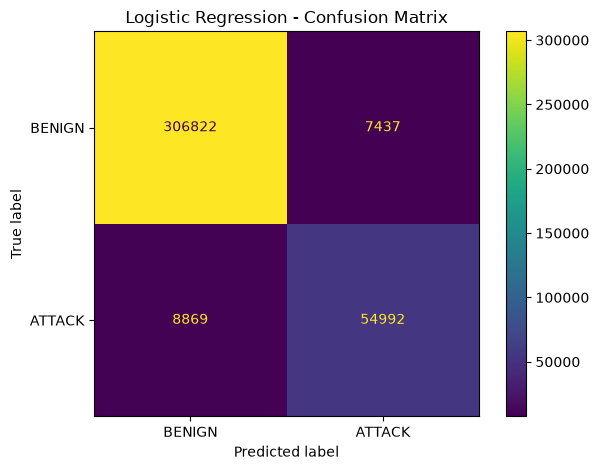

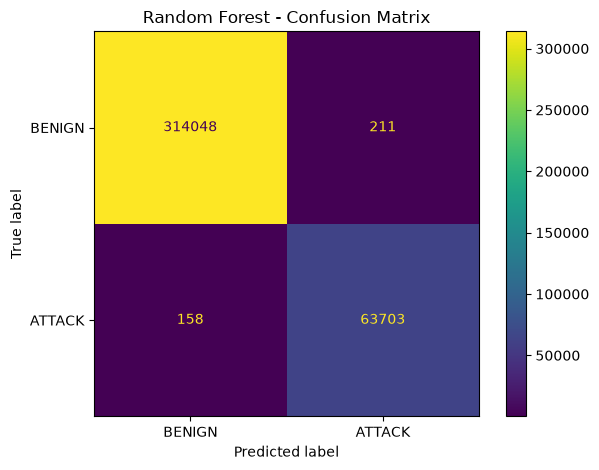

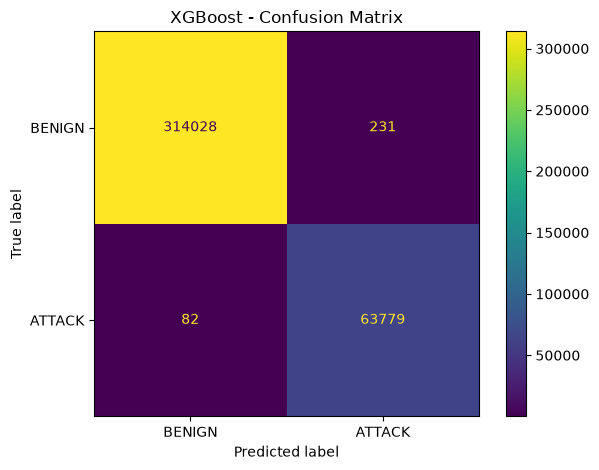

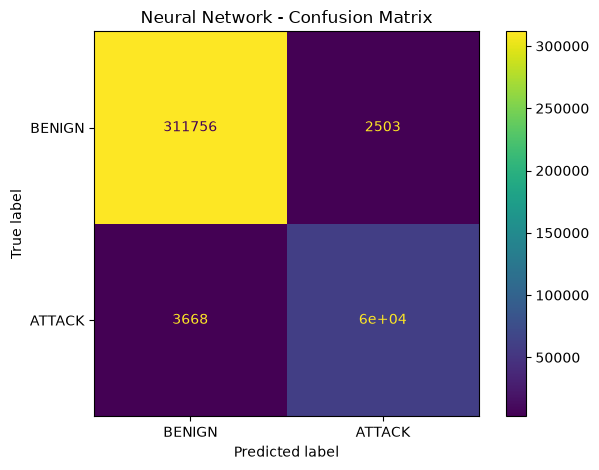

In [16]:
plot_confusion_matrix(
    y_val,
    y_val_pred_lr,
    "Logistic Regression"
)

plot_confusion_matrix(
    y_val,
    y_val_pred_rf,
    "Random Forest"
)

plot_confusion_matrix(
    y_val,
    y_val_pred_xgb,
    "XGBoost"
)

plot_confusion_matrix(
    y_val,
    y_val_pred_nn,
    "Neural Network"
)

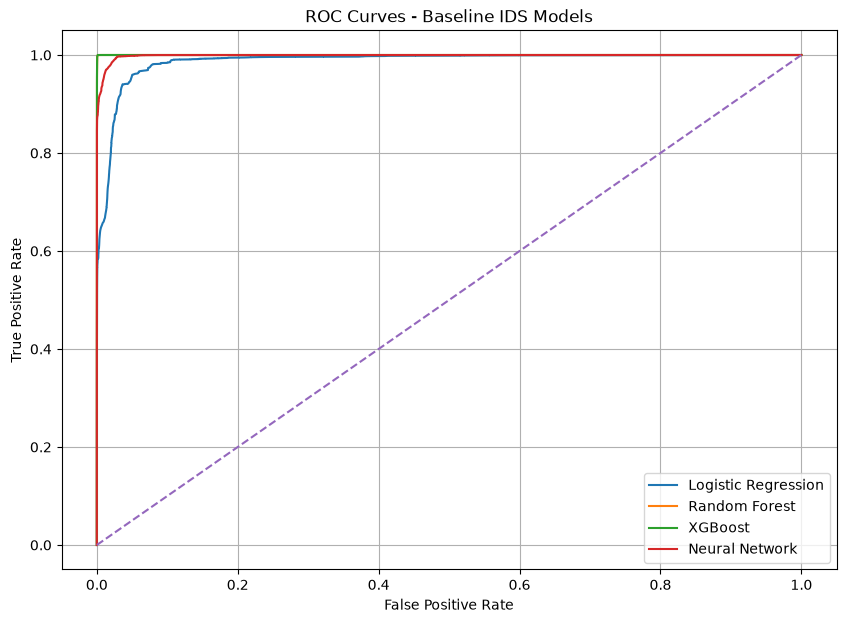

In [17]:
from sklearn.metrics import roc_curve

models = {
    "Logistic Regression": y_val_prob_lr,
    "Random Forest": y_val_prob_rf,
    "XGBoost": y_val_prob_xgb,
    "Neural Network": y_val_prob_nn
}

plt.figure(figsize=(10, 7))

for name, probabilities in models.items():

    fpr, tpr, _ = roc_curve(
        y_val,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Baseline IDS Models")
plt.legend()
plt.grid()
plt.show()

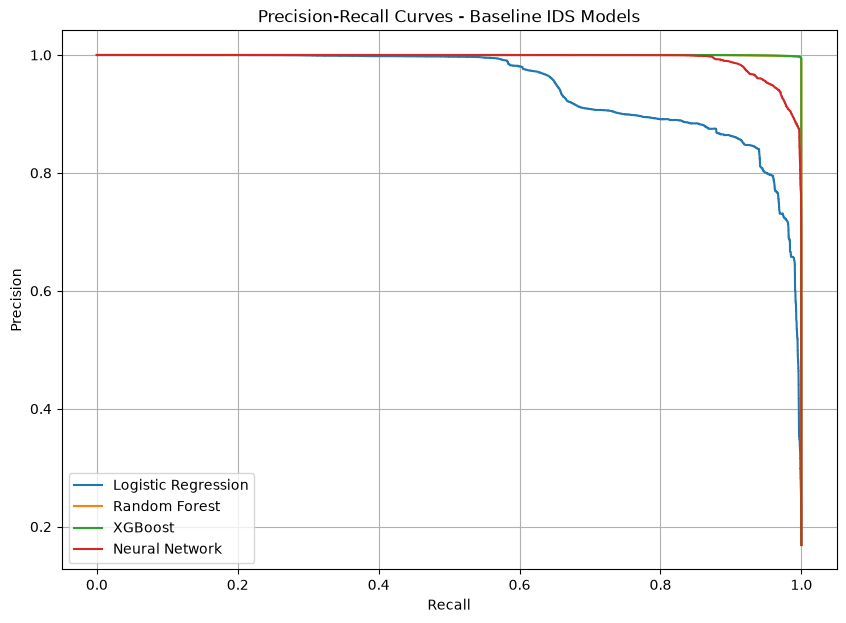

In [18]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

for name, probabilities in models.items():

    precision, recall, _ = precision_recall_curve(
        y_val,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curves - Baseline IDS Models"
)
plt.legend()
plt.grid()
plt.show()

In [19]:
RESULTS_DIR = Path("../experiments/results")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

baseline_df.to_csv(
    RESULTS_DIR /
    "baseline_evaluation.csv"
)

print(
    "Baseline evaluation saved."
)

Baseline evaluation saved.
